# Modeling Power Outages by County in Maine

The goal of this notebook is to use sktime to predict customers.out in the counties in Maine.

Maine has only sixteen counties with a wide range of topography and population. 
If we are able to set up hierarchical methods for ME, we should be able to scale up to the entire US.

The outline of the notebook is:
- Setup
    - Import packages
    - Load and arrange the data
    - Set the y-variable
    - Set the features
    - Restrict to a smaller set for testing purposes
- EDA
    - Graph customers.out as time series for each county
    - Make ACF graphs for each county to identify potential seasonality
    - Check for stationarity
    - Make PACF graphs to suggest model order
- Set up the expanding window forecaster
- Analysis with XGBoost
    - Set up the forecaster
    - Use the built-in evaluate function with customers_out
    - Use custom code to evaluate max customers out over the next 4 intervals

## SKTime Guides

The basic sktime workflow is:
1. Preparation of the data
2. Specification of the time points for which forecasts are requested. This uses a numpy.array or the ForecastingHorizon object.
3. Specification and instantiation of the forecaster. This follows a scikit-learn-like syntax; forecaster objects follow the familiar scikit-learn BaseEstimator interface.
4. Fitting the forecaster to the data, using the forecaster's fit method
5. Making a forecast, using the forecaster's predict method

Following guides at:
- https://github.com/sktime/sktime/blob/main/examples/01_forecasting.ipynb
- https://www.sktime.net/en/latest/examples/01c_forecasting_hierarchical_global.html

## Imports

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sktime.utils.plotting import plot_series

from sktime.split import temporal_train_test_split
from sktime.split import ExpandingWindowSplitter

from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.arima import ARIMA
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.sarimax import SARIMAX
from sktime.forecasting.varmax import VARMAX
from sktime.forecasting.compose import ForecastingPipeline
from sktime.forecasting.model_evaluation import evaluate

# Note that we'll need to install darts for xgb to work:
# conda install -c conda-forge -c pytorch u8darts-all
from sktime.forecasting.darts import DartsXGBModel

from sklearn.preprocessing import StandardScaler

from sktime.transformations.series.adapt import TabularToSeriesAdaptor

from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.performance_metrics.forecasting import MeanSquaredError

# There is a futurewarning from sklearn that will be addressed eventually in sktime; suppressing it for now.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Load and Arrange the Data

We'll load the dataset with eaglei, noaa, era5, county-level, and engineered variables

We'll restrict to our training set (pre-2022)

For now, we'll also restrict ourselves to Maine, which has just 16 counties--a sufficient number to let us try out the techniques before deploying on the entire country

In [6]:
#Load the engineered data
df = pd.read_parquet('../Data/Merged_Data/eaglei_noaa_era5_engineered.parquet')

In [7]:
# Sort df
df = df.sort_values(by=['fips_code', 'datetime'])

# Restrict df to years prior to 2022
# For now, we'll just focus on Maine
df = df[df['STUSPS'] == 'ME']
df = df[df['YEAR'] < 2022]

# The first nonzero entry for customers_out in Maine was November 2nd, 2014
df = df[df['datetime'] > '2014-11-01']

# Use fips_code and datetime as indices
df = df.set_index(['fips_code', 'datetime'])

#Sort df
#df = df.sort_index()

## Set the y-variable (customers_out)

We'll need to do a bit of work with the index to make it compatible with sktime.
Specifically, we'll need to recreate the multiindex and imbue it with a frequency

In [8]:
y = df['customers_out']

#Set the multiindex on y
y = y.reset_index()

#Use fips_code and datetime as a multiindex on y
y = y.set_index(['fips_code', 'datetime'])

#Sort y
y = y.sort_index()

# Note that datetime doesn't have an embedded frequency; we'll need to set this manually
#Convert DatetimeIndex to PeriodIndex with 6-hour frequency
y.index = y.index.set_levels(y.index.levels[1].to_period('6h'), level=1)

# Set the features

In [10]:
# Create a new variable dividing POPULATION divided by AREA
df['density'] = df['POPULATION'] / df['AREA']

# Note: Not currently including Subregion b/c we'd need to convert to a dummy variable

features = ['Pct_Buried_Lines','centroid_longitude','centroid_latitude','density',
       'event_count SnowIce',
       'event_count Flood', 'event_count Storm', 'event_count Hurricane',
       'event_count Heat', 'event_count Fire', 'event_count Wind',
       'event_count Ocean', 'event_count Other', 't2m', 'sf', 'tp', 't2m_mean',
       't2m_max', 'sf_mean', 'sf_max', 'tp_mean', 'tp_max', 'wind_speed',
       'neighbor_mean_wind_speed', 'neighbor_max_wind_speed', 'sf_12h',
       'sf_24h', 'tp_12h', 'tp_24h']


X = df[features]

#Set the multiindex on y and X
X = X.reset_index()

#Use fips_code and datetime as a multiindex
X = X.set_index(['fips_code', 'datetime'])

#Sort
X = X.sort_index()

# Note that datetime doesn't have an embedded frequency; we'll need to set this manually
#Convert DatetimeIndex to PeriodIndex with 6-hour frequency
X.index = X.index.set_levels(X.index.levels[1].to_period('6h'), level=1)

## Restrict to a smaller set for testing

In [75]:
# Restrict to a smaller data set for testing purposes
y_small = y.groupby(level=0).tail(1000)
X_small = X.groupby(level=0).tail(1000)

# EDA

## Graphing the Data

We'll start by making some plots of the data to get a sense of the sparsity of the data

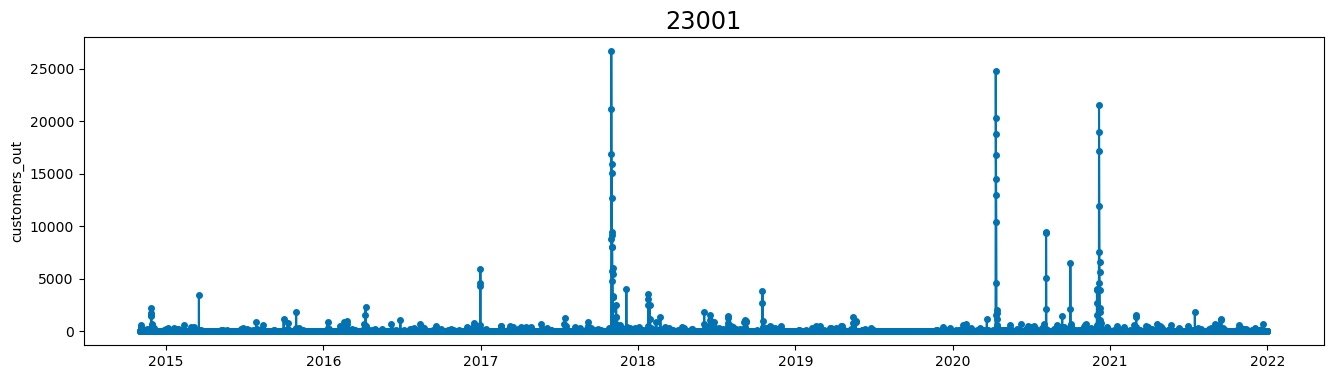

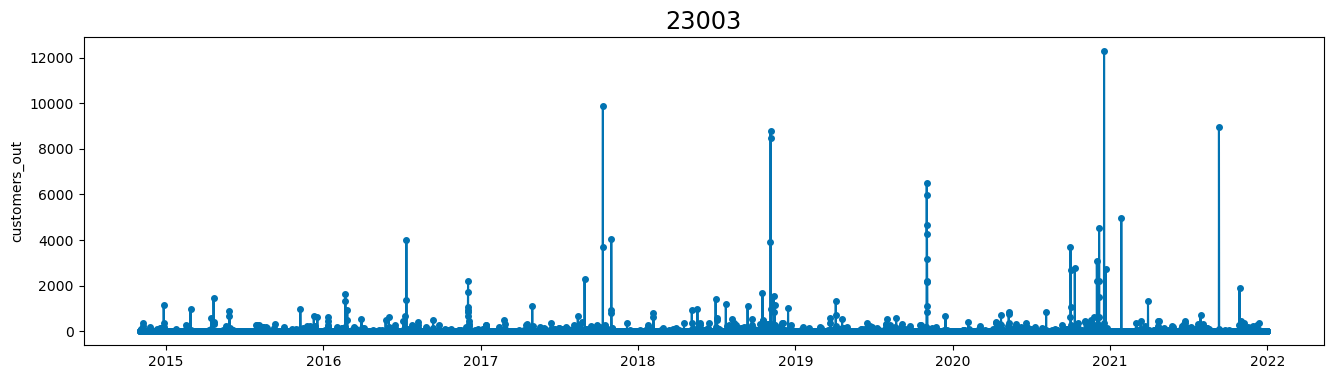

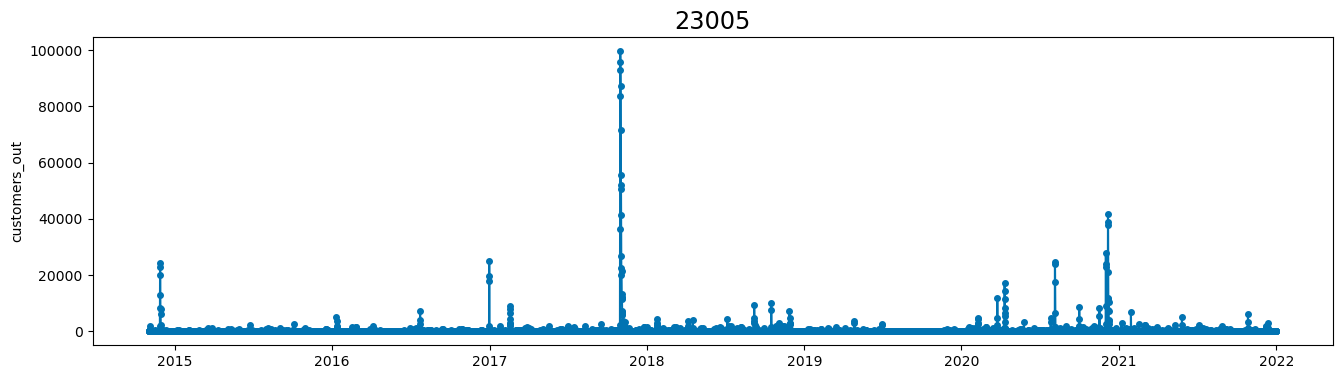

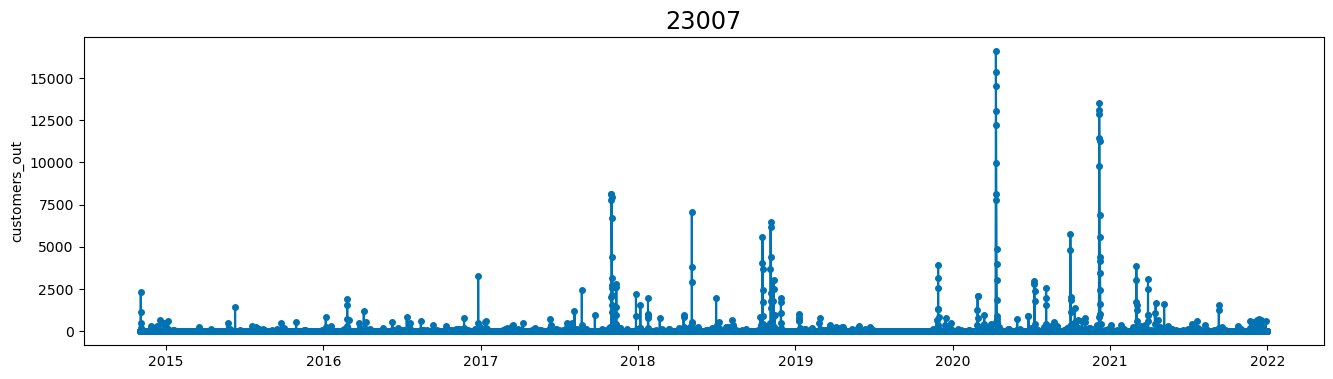

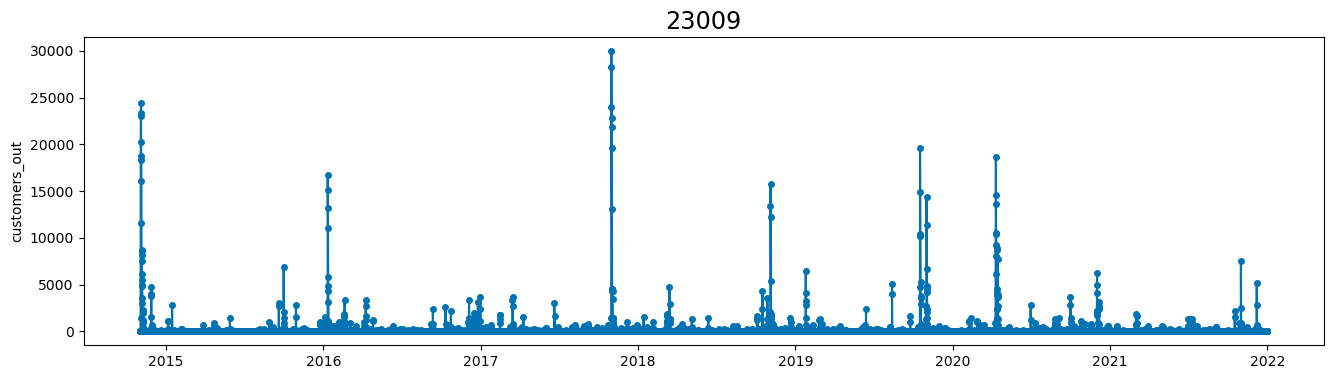

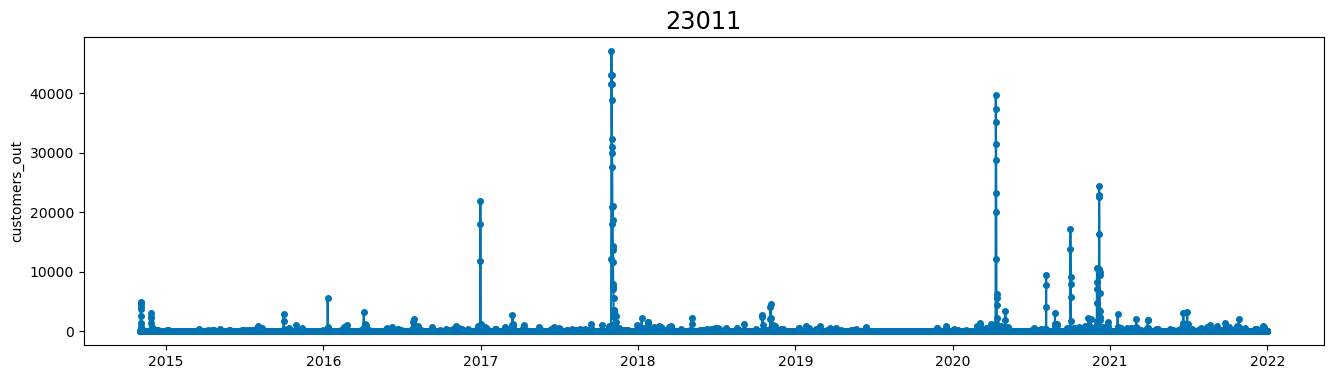

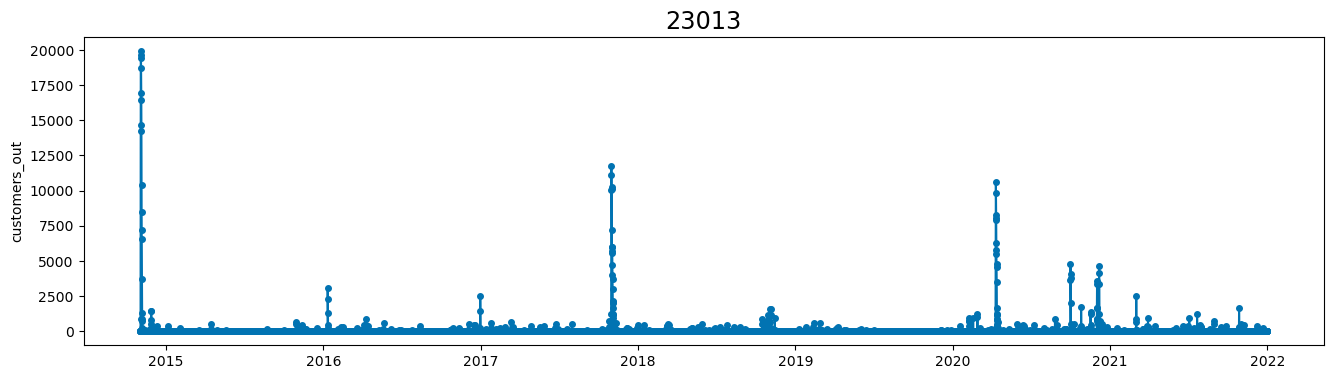

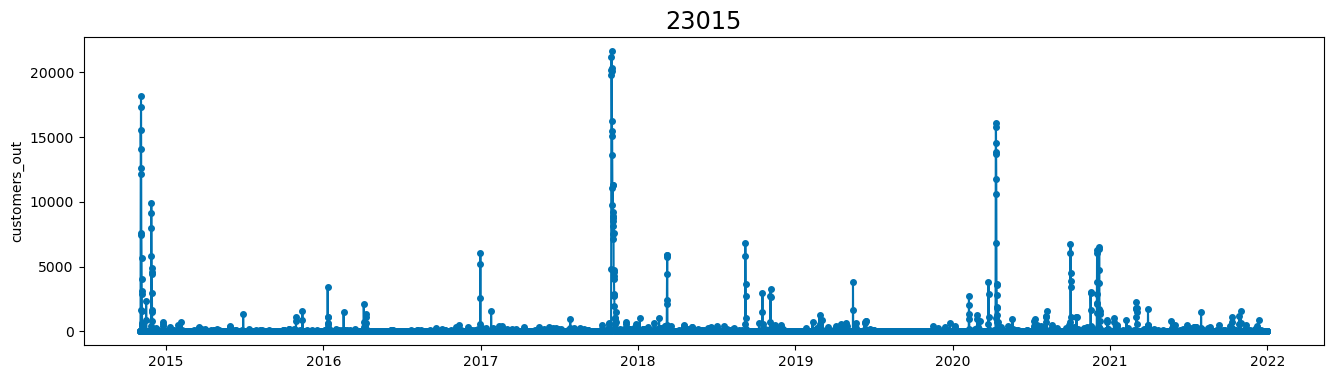

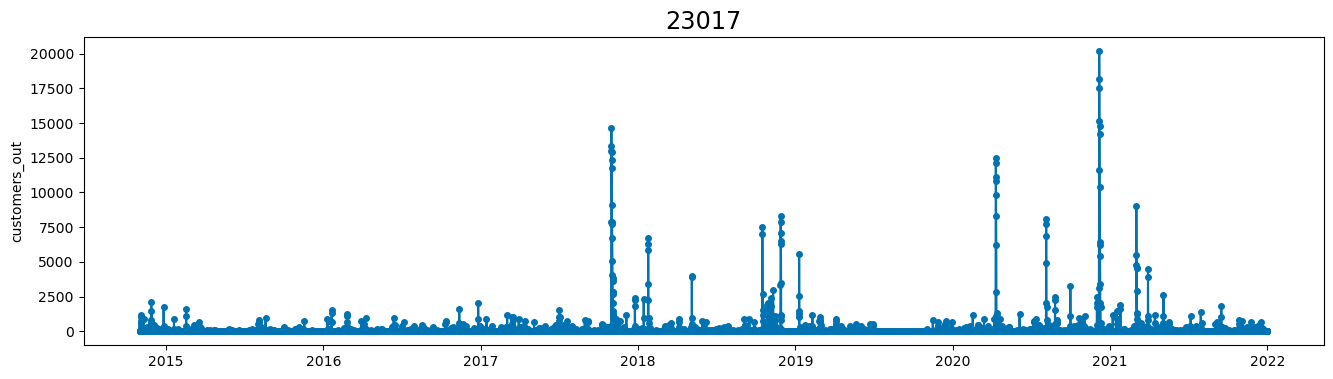

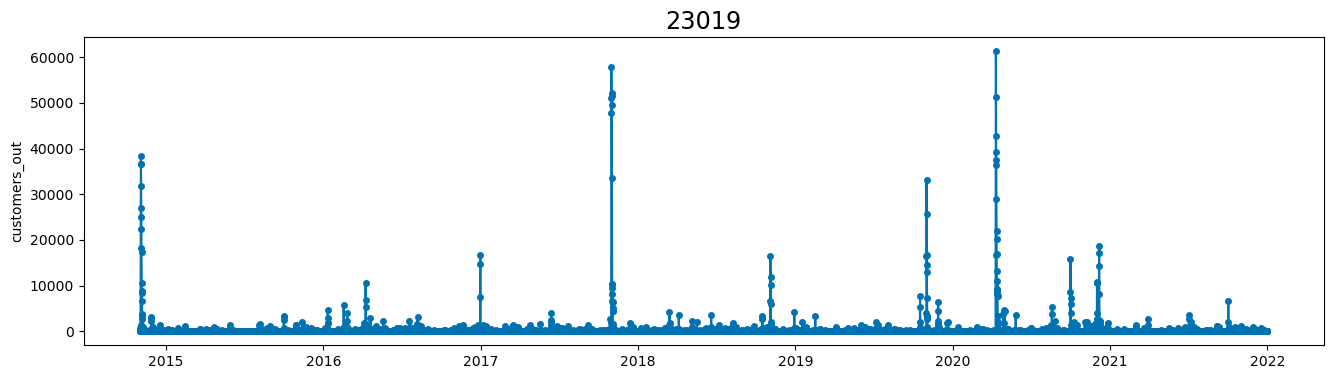

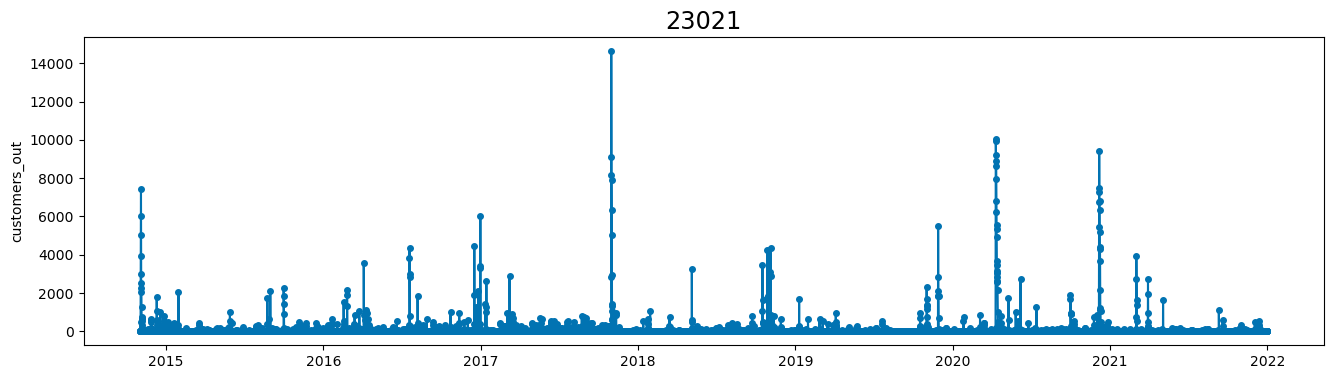

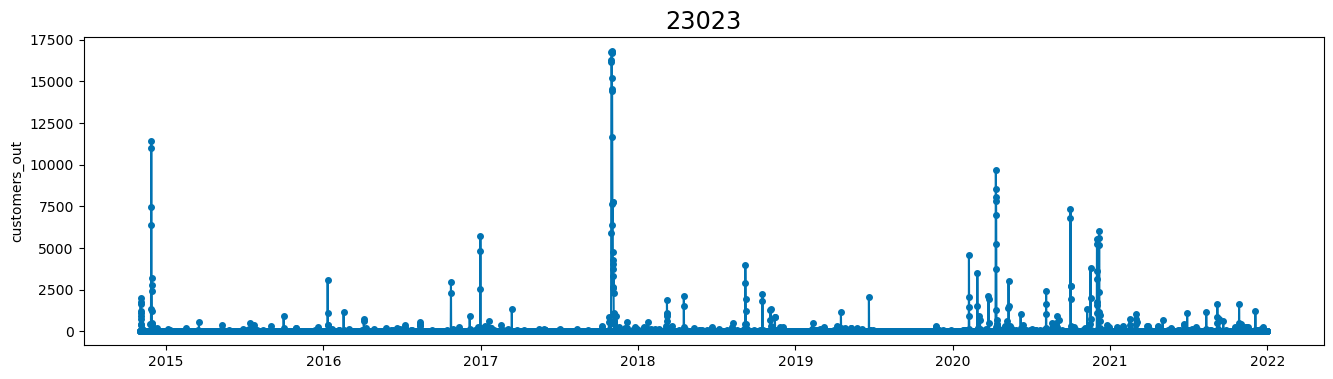

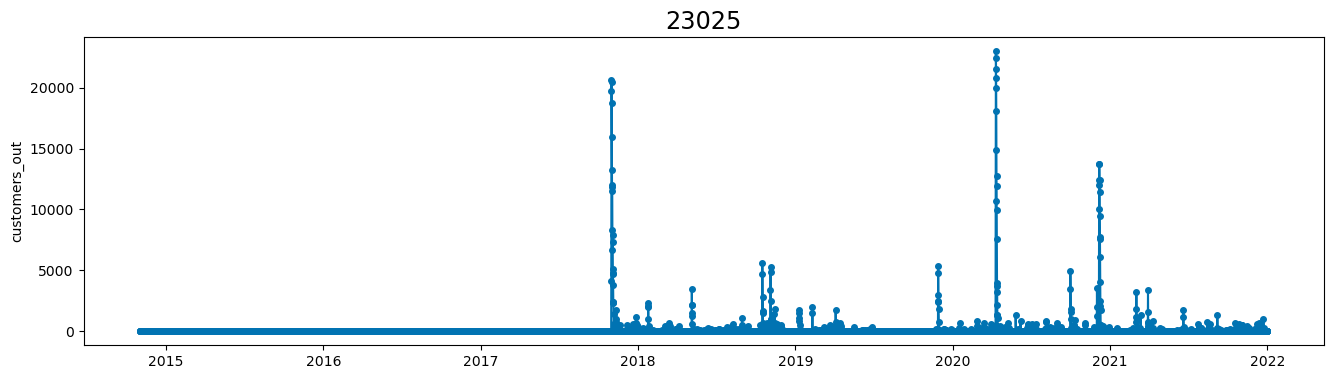

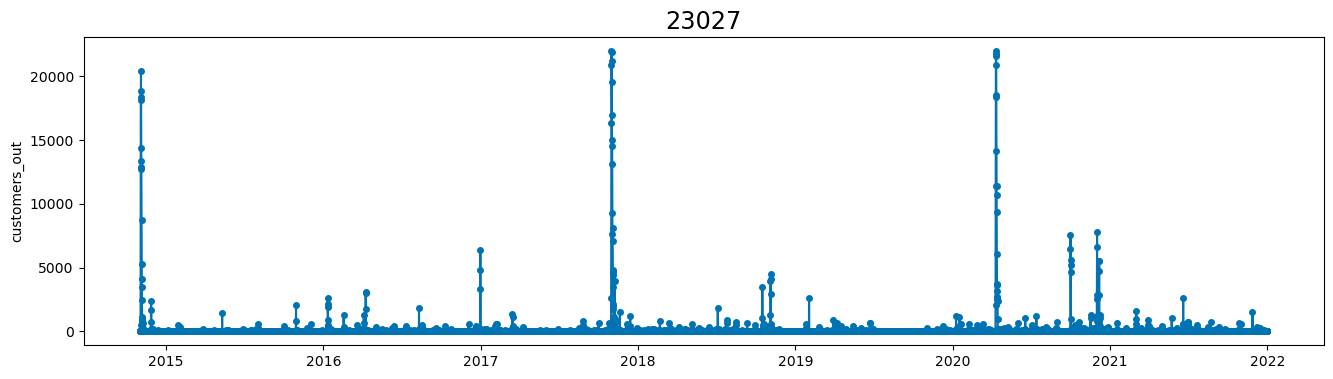

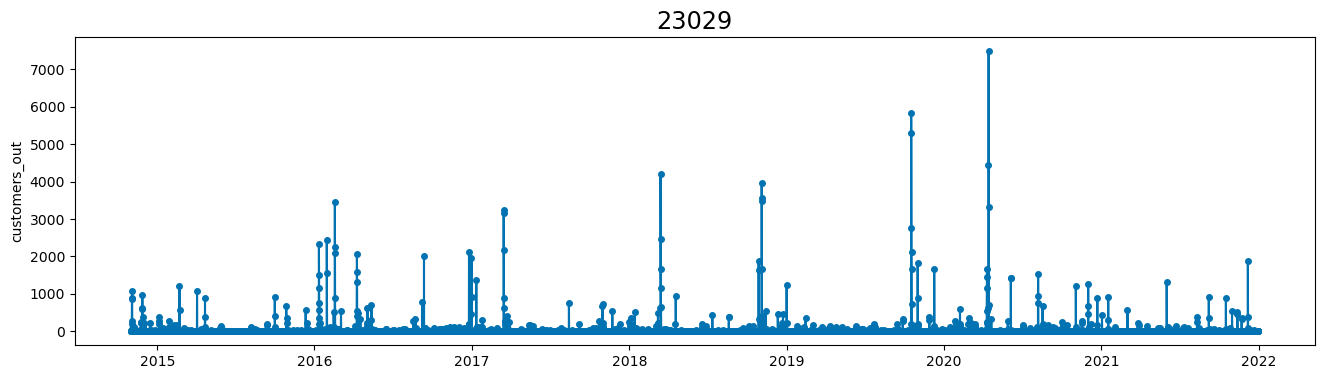

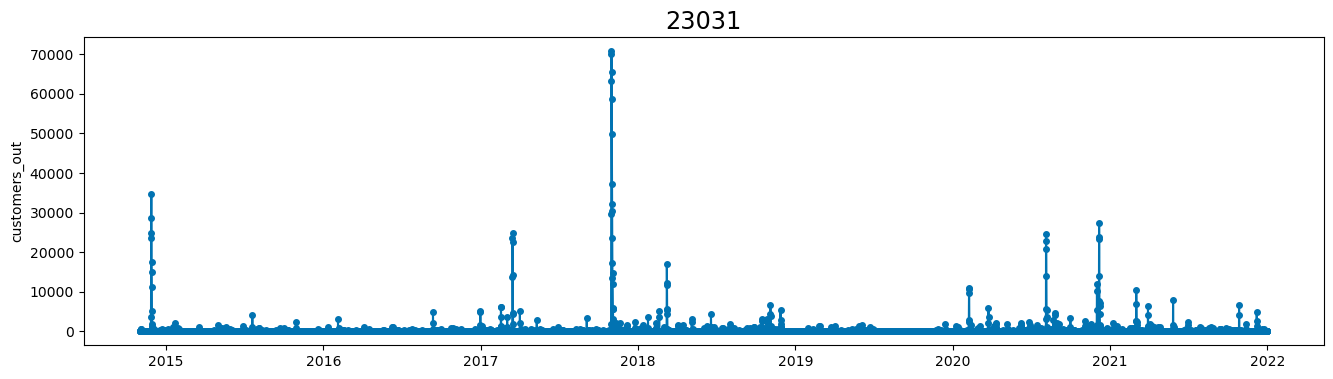

In [12]:
#For each value of fips_code, plot the value of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    plot_series(y_fips, title=fips_code)

## ACF, Stationarity, and PACF plots

We'll make an autocorrelation and partial autocorrelation plot for each of the counties.

The ACF plots suggest that there are correlations with up to 15-20 lags, which corresponds to 4-5 days. There doesn't appear to be any consistent seasonality.

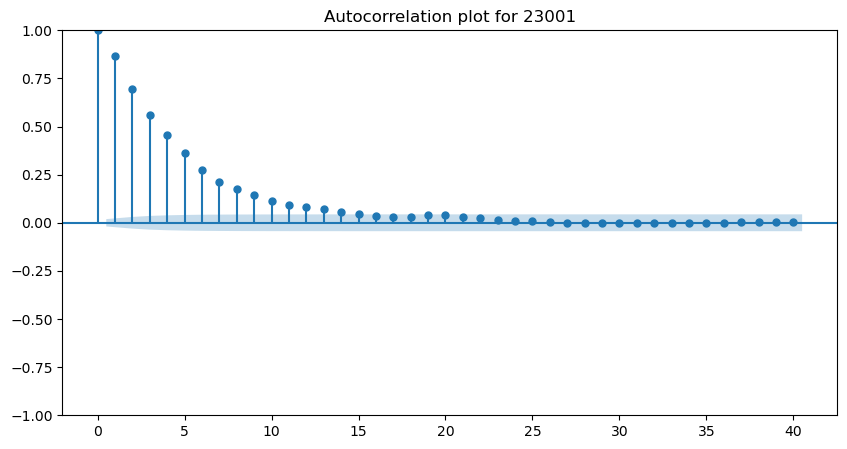

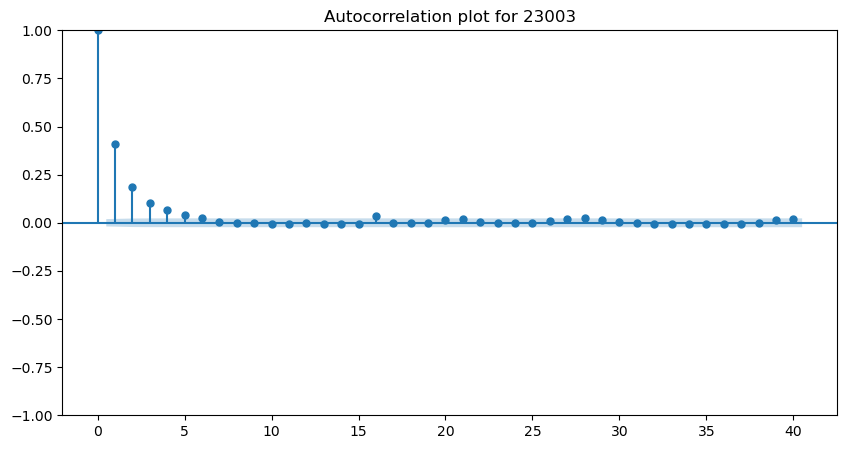

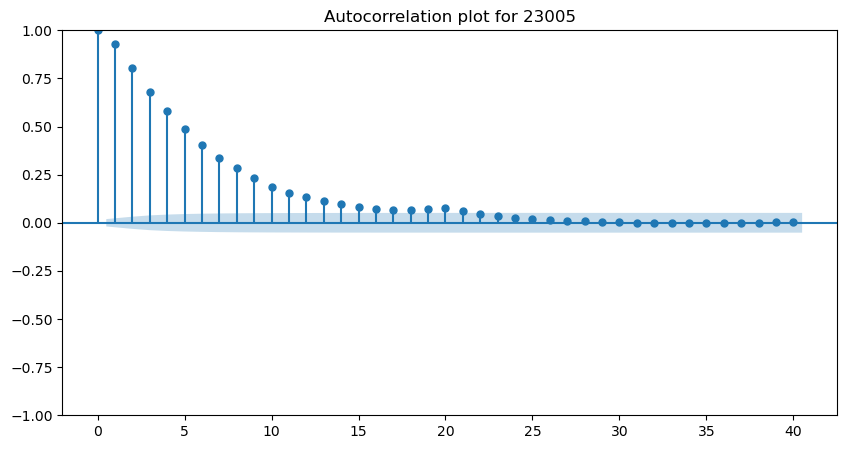

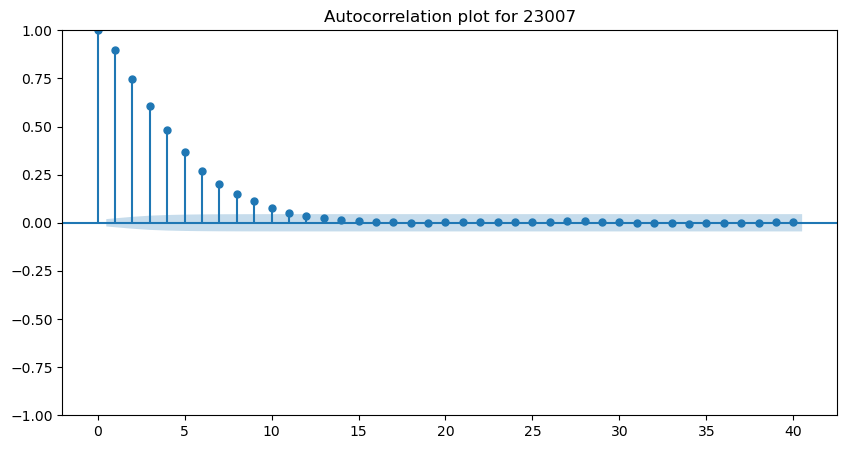

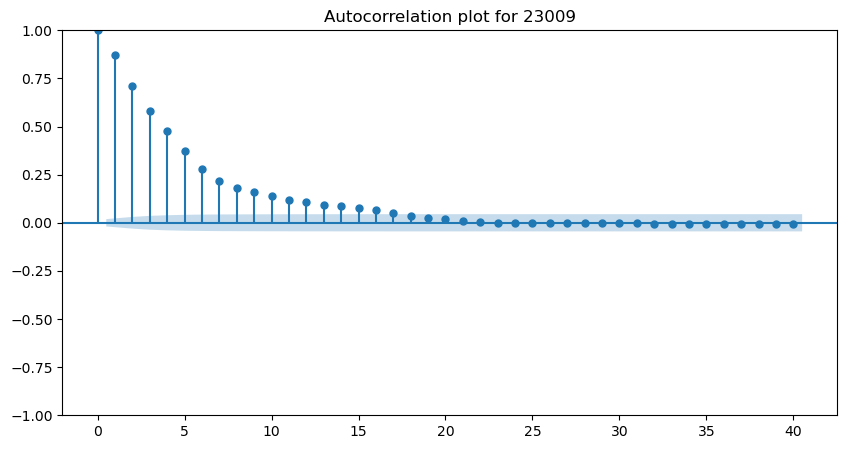

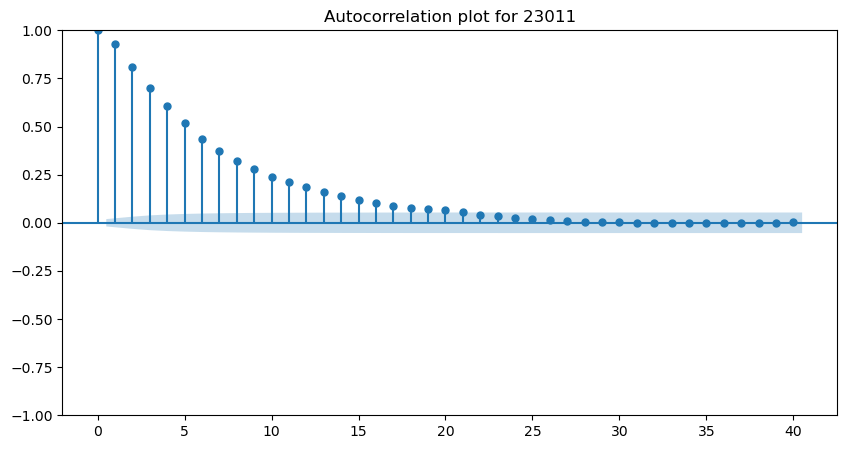

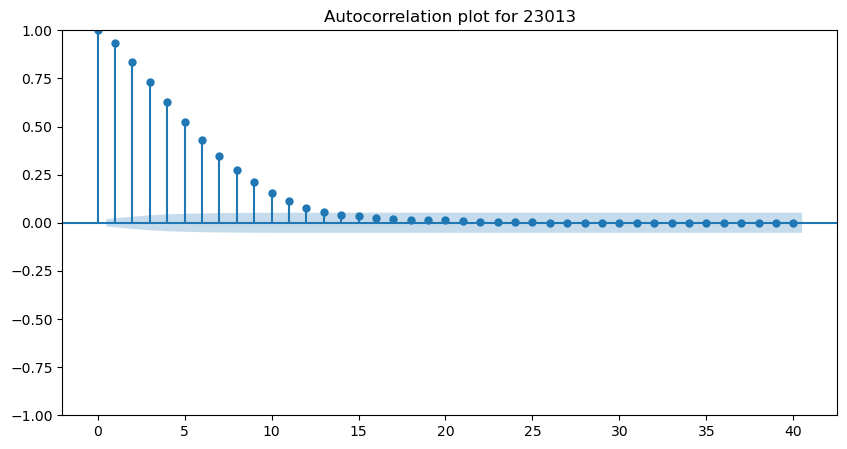

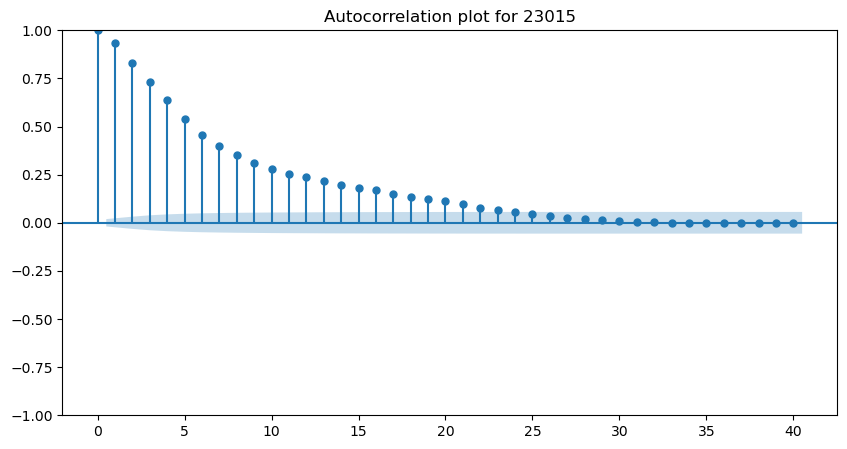

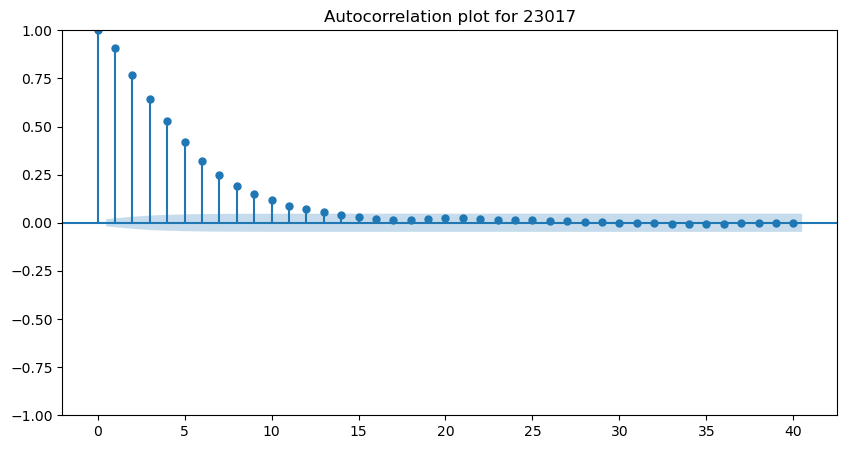

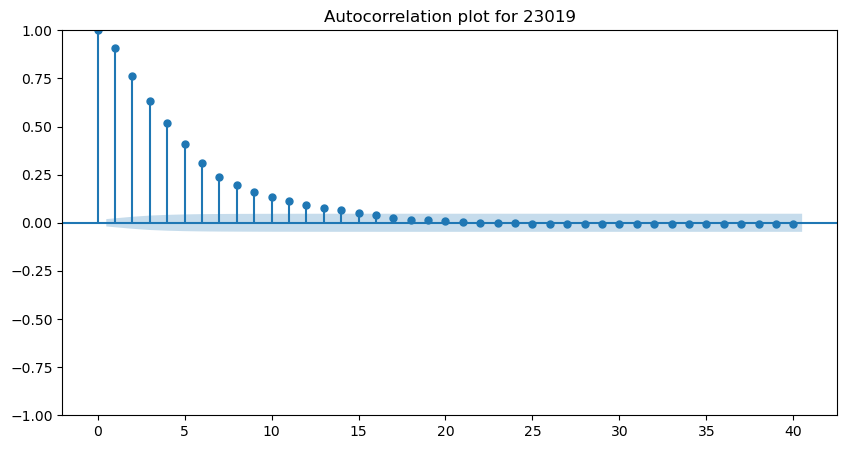

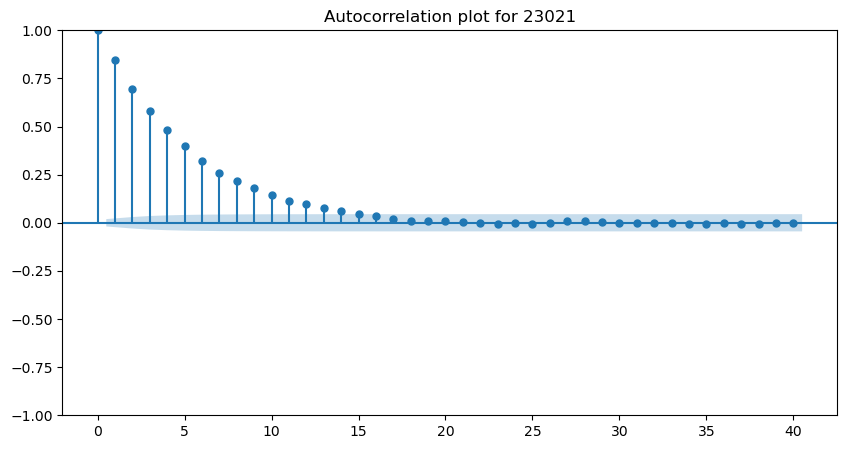

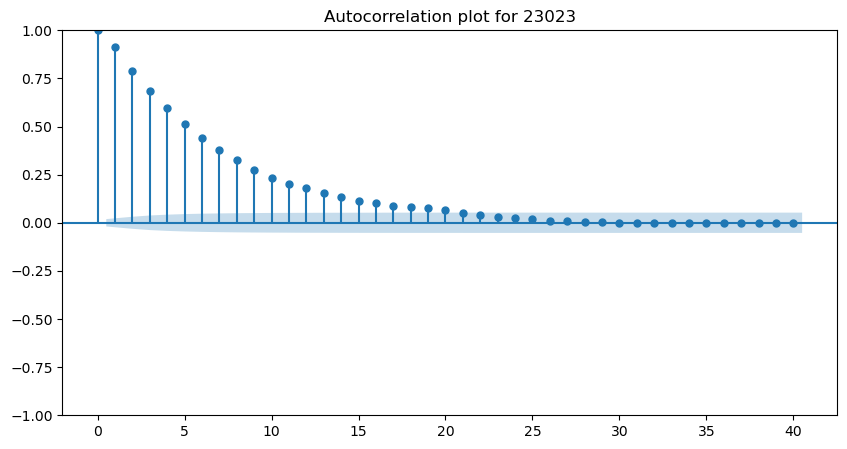

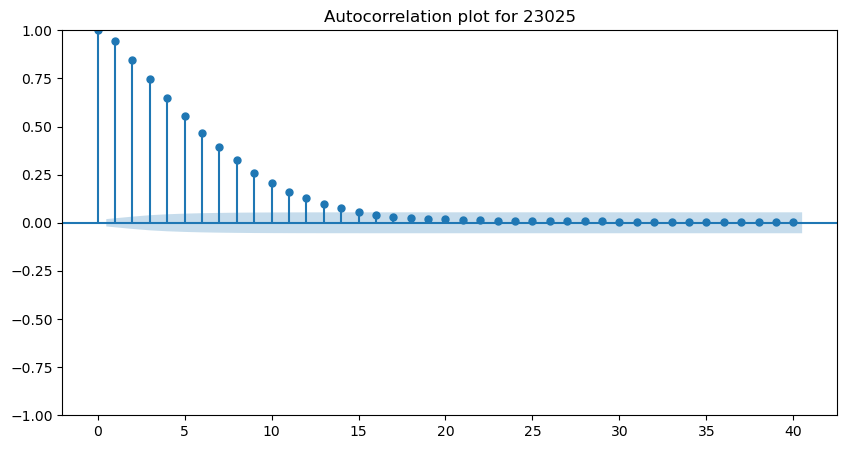

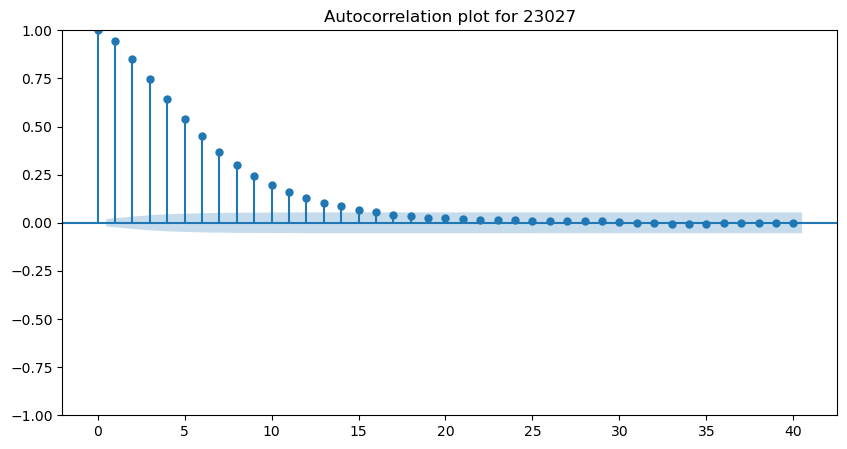

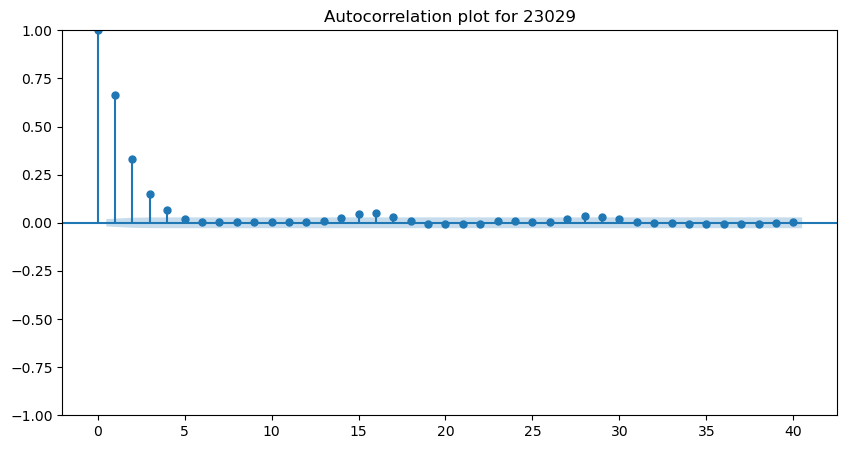

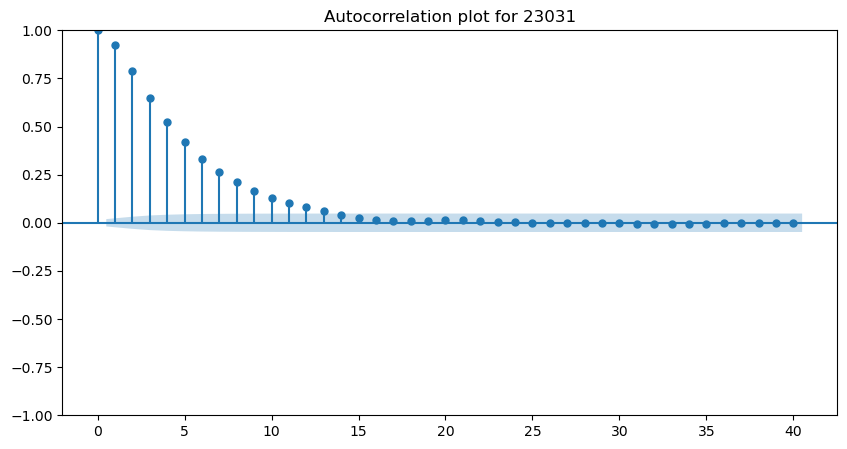

In [14]:
#For each value of fips_code use statsmodels to make an autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sm.graphics.tsa.plot_acf(y_fips['customers_out'], lags=40, ax=ax)
    plt.title(f'Autocorrelation plot for {fips_code}')
    plt.show()

### Testing for stationarity

We'll use an augmented Dickey-Fuller test. All the p-values are quite tiny, suggesting stationarity.

This suggests that an autoregressive model is appropriate.

In [15]:
# Create a numpy array to hold the fips_codes and p-values
p_values = np.zeros((16, 2))
i=0

#For each value of fips_code, run the Augmented Dickey-Fuller test
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    result = sm.tsa.stattools.adfuller(y_fips['customers_out'])
    p_values[i,0]=int(fips_code)
    p_values[i,1]=result[1]
    i=i+1
p_values

array([[2.30010000e+04, 2.02266229e-30],
       [2.30030000e+04, 0.00000000e+00],
       [2.30050000e+04, 1.05219007e-29],
       [2.30070000e+04, 0.00000000e+00],
       [2.30090000e+04, 0.00000000e+00],
       [2.30110000e+04, 2.98314558e-30],
       [2.30130000e+04, 0.00000000e+00],
       [2.30150000e+04, 1.69490413e-29],
       [2.30170000e+04, 0.00000000e+00],
       [2.30190000e+04, 0.00000000e+00],
       [2.30210000e+04, 0.00000000e+00],
       [2.30230000e+04, 1.19006282e-29],
       [2.30250000e+04, 2.18964817e-30],
       [2.30270000e+04, 9.31721772e-29],
       [2.30290000e+04, 0.00000000e+00],
       [2.30310000e+04, 0.00000000e+00]])

### PACF Plots

There is quite a bit of variation from county to county. The first and second lags are statistically significant for all counties. It isn't uncommon for the fourth and fith lags to also be statistically significant. 

This suggests we might use a fifth-order autoregressive model.

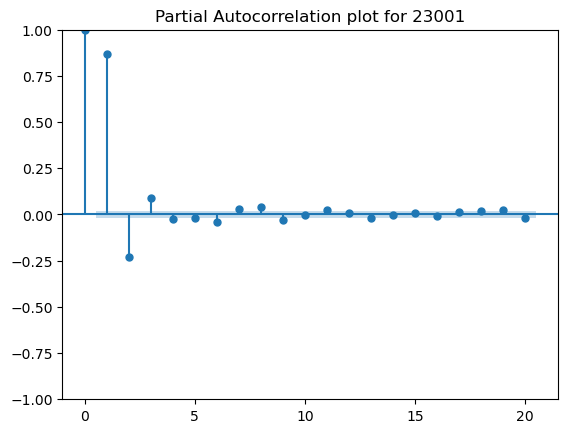

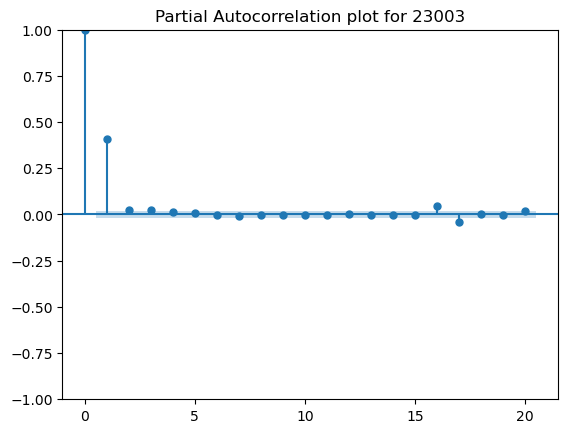

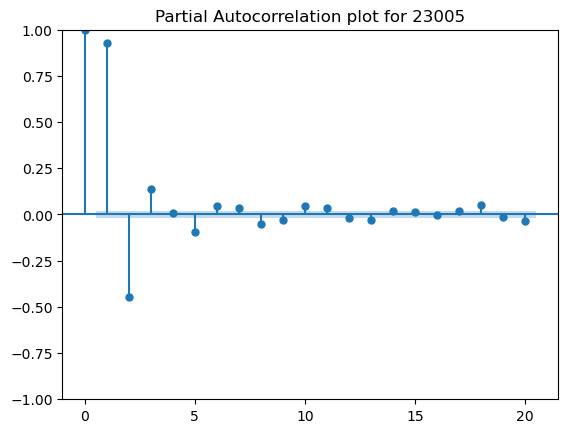

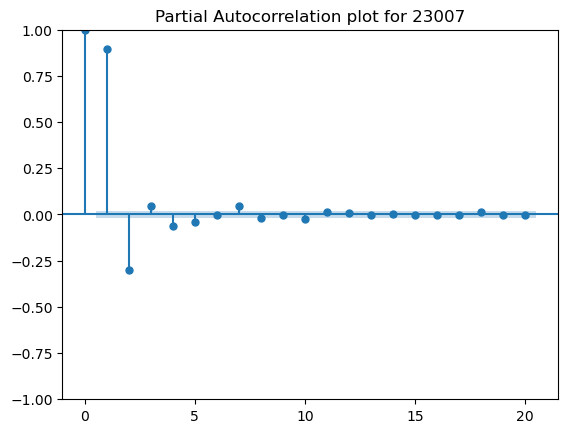

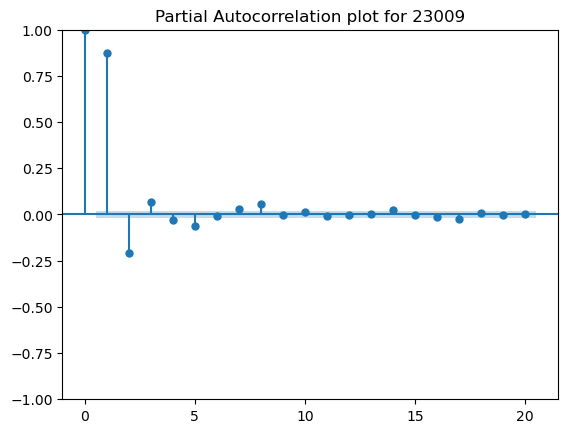

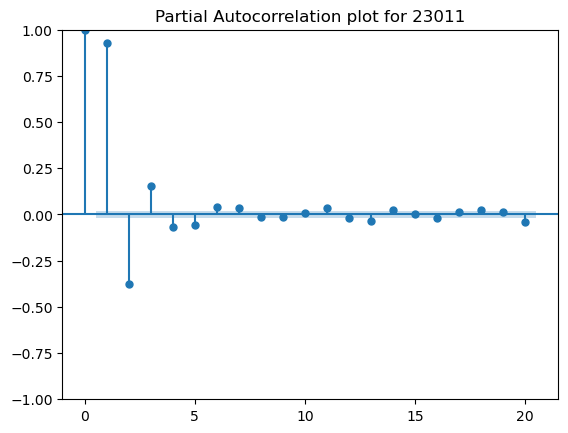

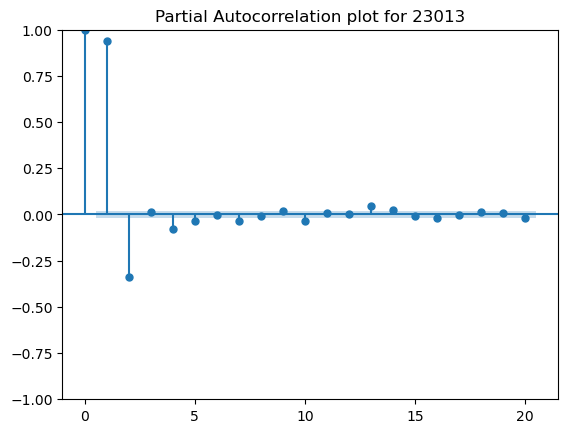

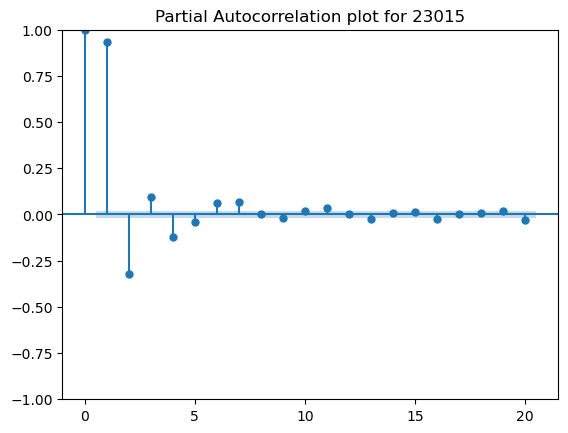

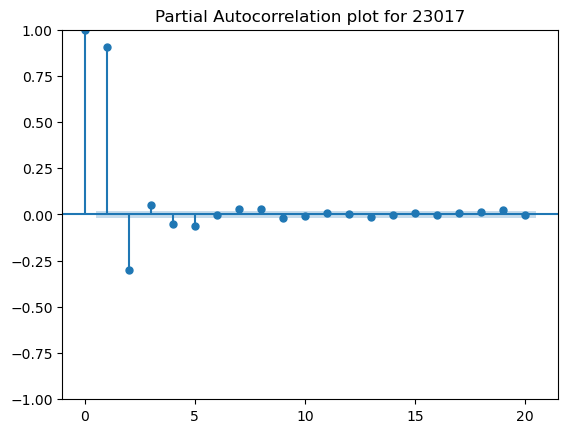

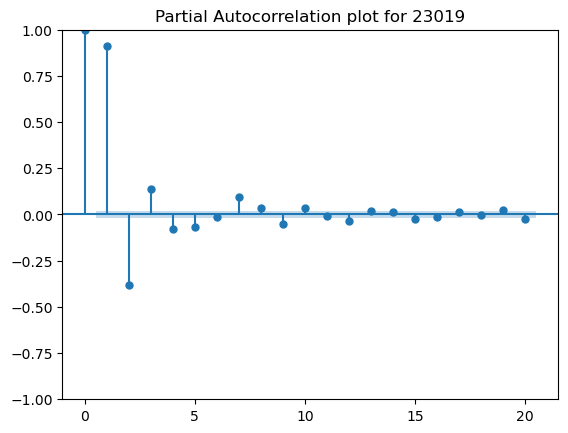

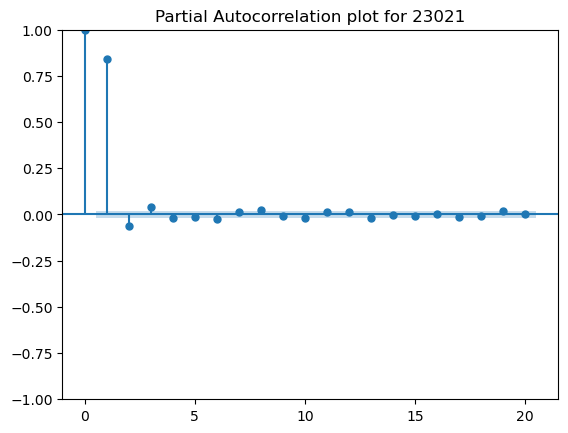

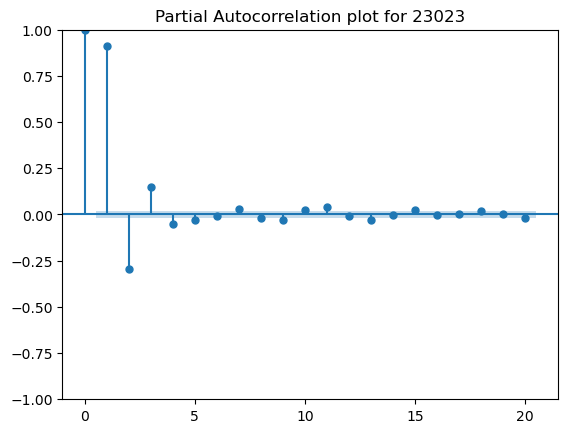

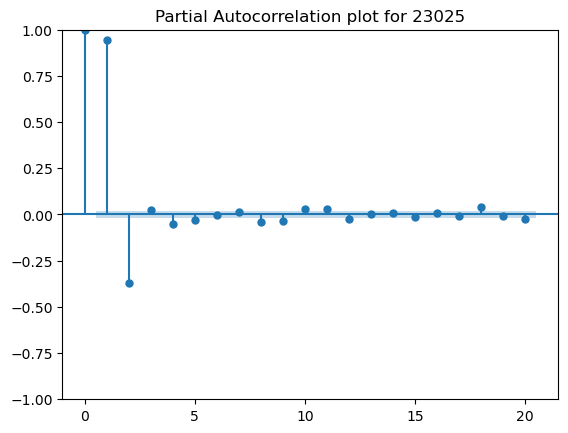

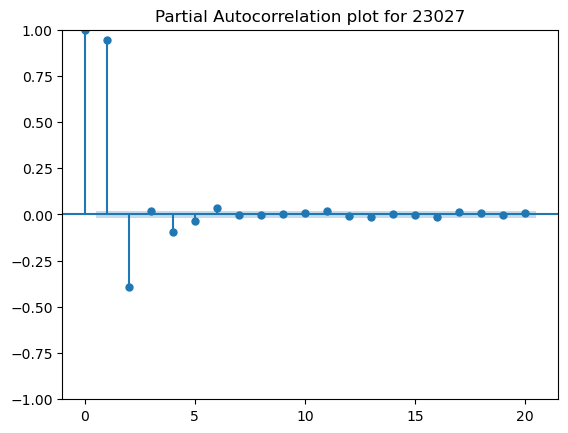

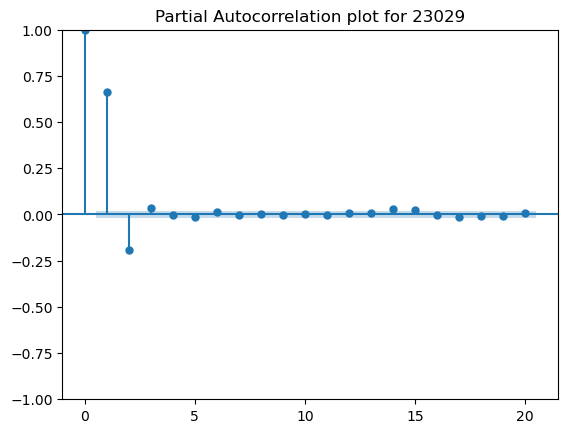

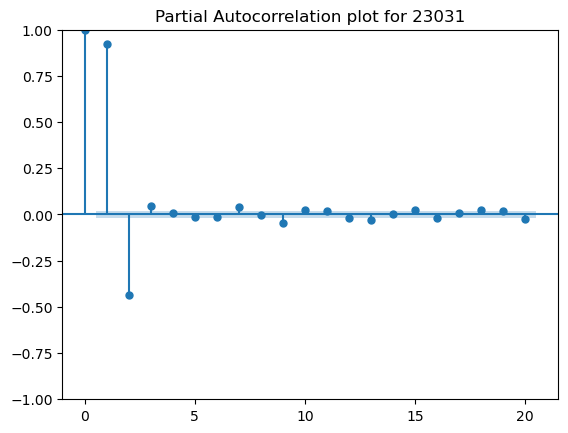

In [16]:
#For each value of fips_code make a partial autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    sm.graphics.tsa.plot_pacf(y_fips, lags=20, method='ols')
    plt.title(f'Partial Autocorrelation plot for {fips_code}')
    plt.show()

# Expanding Window Forecaster

In [77]:
fh = np.arange(1, 5)   #Forecasting horizon - we'll need this later
#fh = ForecastingHorizon(13, is_relative=False)

# Define the ExpandingWindowSplitter
ews = ExpandingWindowSplitter(
    initial_window=500,      # Length of the initial window
    fh = np.arange(1,5),    # Forecasting horizon
    step_length=4)          # Step length between windows

### Make a plot of the train and test windows

In [29]:
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator

def plot_windows(y, train_windows, test_windows, title=""):
    """Visualize training and test windows."""
    simplefilter("ignore", category=UserWarning)

    def get_y(length, split):
        # Create a constant vector based on the split for y-axis."""
        return np.ones(length) * split

    n_splits = len(train_windows)
    n_timepoints = len(y)
    len_test = len(test_windows[0])

    train_color, test_color = sns.color_palette("colorblind")[:2]

    fig, ax = plt.subplots(figsize=plt.figaspect(0.3))

    for i in range(n_splits):
        train = train_windows[i]
        test = test_windows[i]

        ax.plot(
            np.arange(n_timepoints), get_y(n_timepoints, i), marker="o", c="lightgray"
        )
        ax.plot(
            train,
            get_y(len(train), i),
            marker="o",
            c=train_color,
            label="Window",
        )
        ax.plot(
            test,
            get_y(len_test, i),
            marker="o",
            c=test_color,
            label="Forecasting horizon",
        )
    ax.invert_yaxis()
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set(
        title=title,
        ylabel="Window number",
        xlabel="Time",
        xticklabels=y.index,
    )
    # remove duplicate labels/handles
    handles, labels = ((leg[:2]) for leg in ax.get_legend_handles_labels())
    ax.legend(handles, labels)

    # Some helper code from sktime

def get_windows(y, cv):
    """Generate windows."""
    train_windows = []
    test_windows = []
    for i, (train, test) in enumerate(cv.split(y)):
        train_windows.append(train)
        test_windows.append(test)
    return train_windows, test_windows

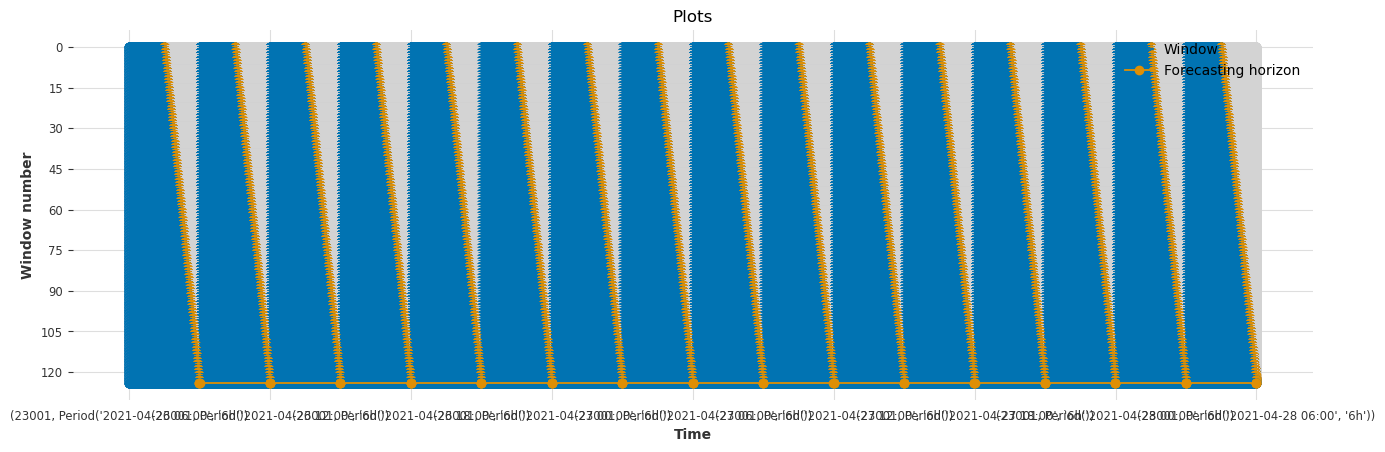

In [78]:
train_windows, test_windows = get_windows(y_small, ews)

plot_windows(y_small, train_windows, test_windows, title="Plots")

## Set up a XGBoost forecaster

In [79]:
# Initialize the DartsXGBModel
# This is just a guess at what the hyperparameters should be...
dartsxgb = DartsXGBModel(
    lags=20,
    output_chunk_length=4,
    kwargs={
        "n_estimators": 100,
        "max_depth": 3,
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
    }
)

#In y_small rename customers_out as c0 for compatibility with the output of the xgb predictor
y_small = y_small.rename(columns={"customers_out": "c0"})

## Evaluate the forecaster for customers_out

In [80]:
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

results = evaluate(
    forecaster=dartsxgb,
    cv=ews,
    y=y_small,
    X=X_small,             # This works with exogeneous variables; predictions are made using predict/predict_proba, or predict_quantiles depending on scoring
    strategy="refit",  # Options are "update" and "refit" (which will reset and fit forecaster via fit), verses updating forecaster via "update"
    scoring=MeanSquaredError(square_root = True),       # None defaults to MeanAbsolutePercentageError(symmetric=True). Options at: https://www.sktime.net/en/stable/api_reference/performance_metrics.html
    return_data=True,   # True means it returns three pd.Series columns for y_train, y_pred, and y_test
    error_score="raise",
    backend=None       # (default is None) Parallelization backend; runs parallel evaluate if specified and strategy="refit"; recommendation to use "dask" or "loky"
)

### Plot the results vs actuals for the first window

Not very good!

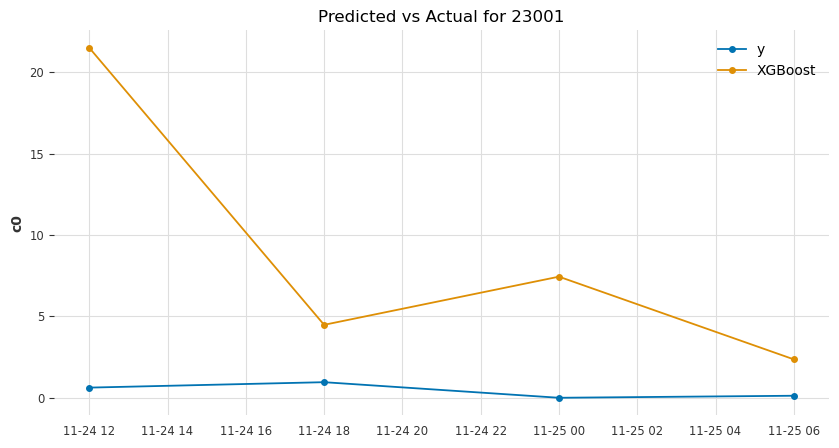

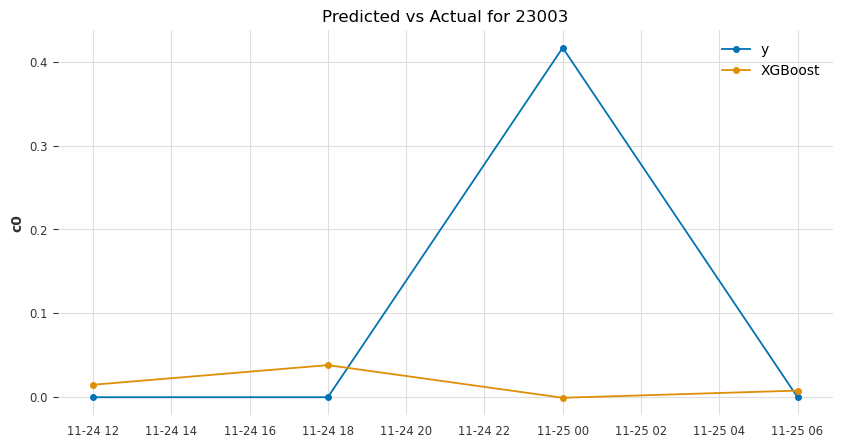

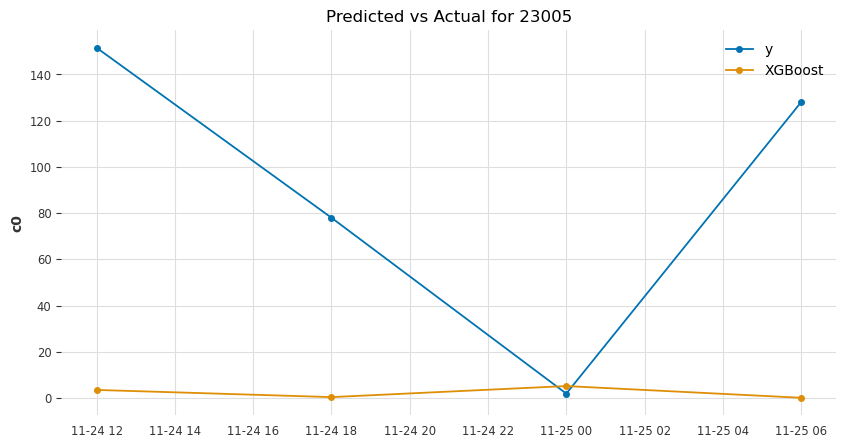

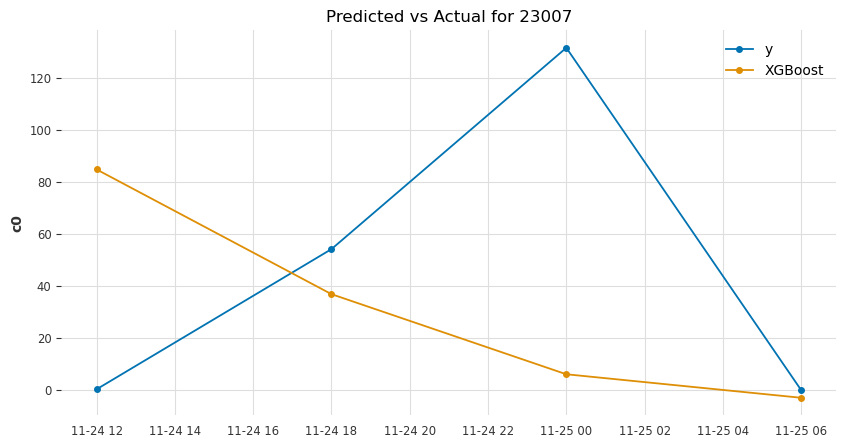

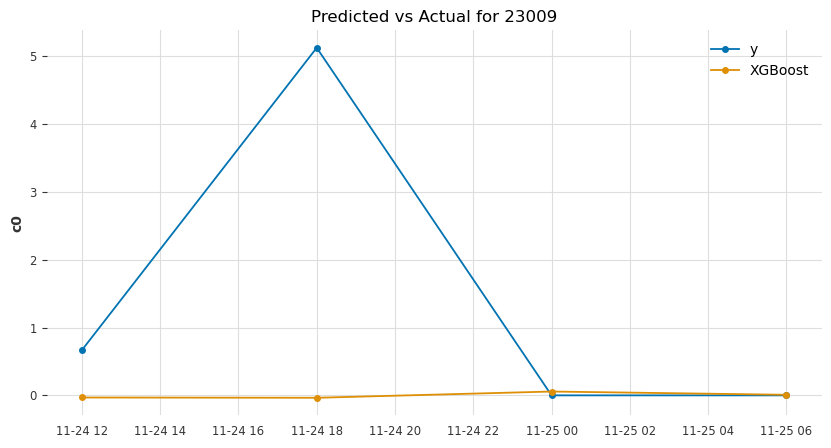

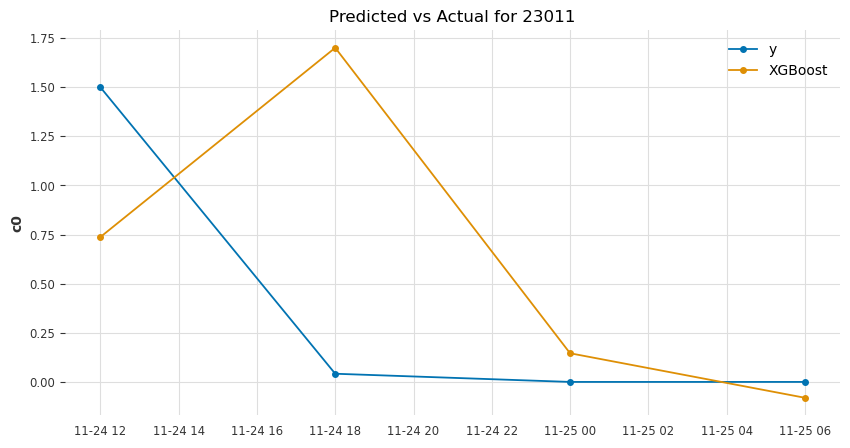

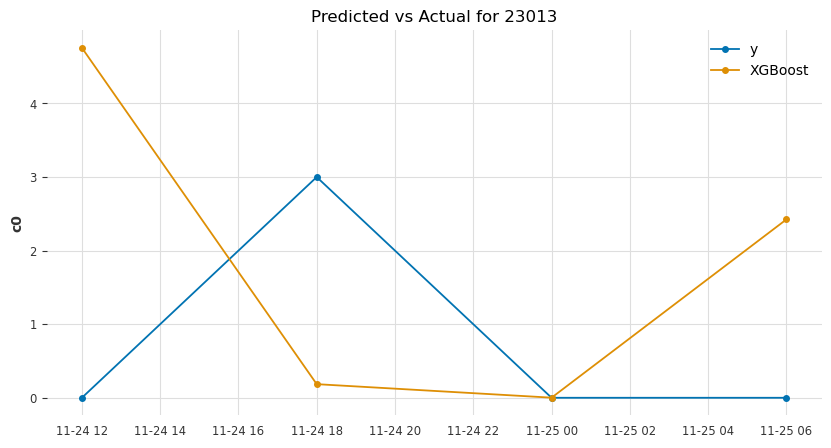

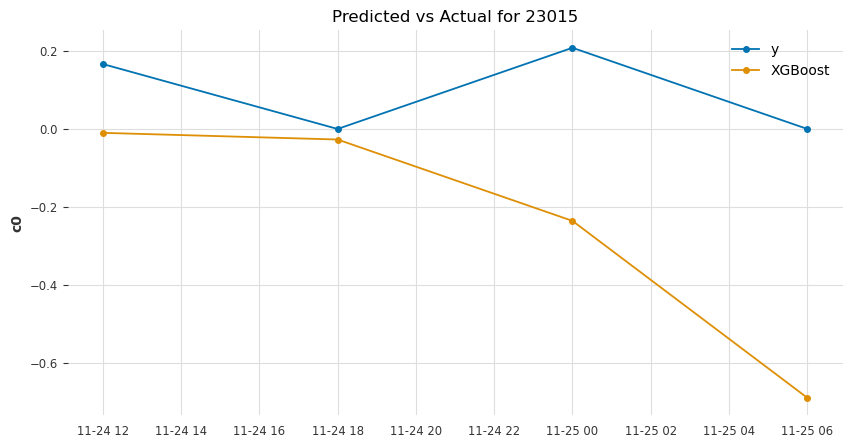

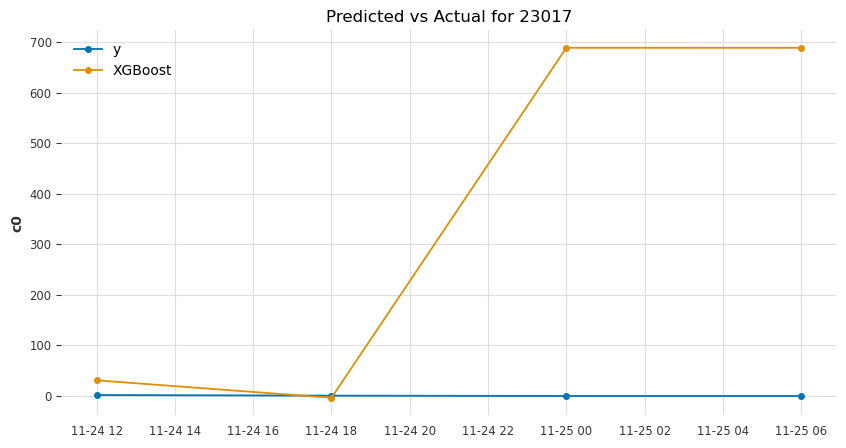

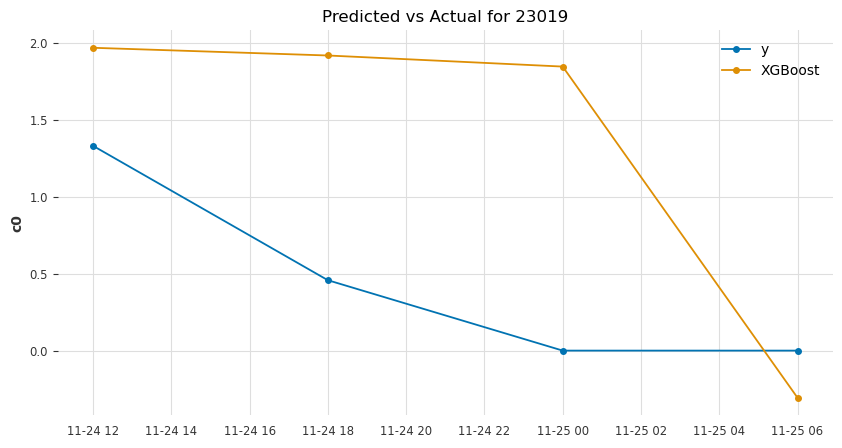

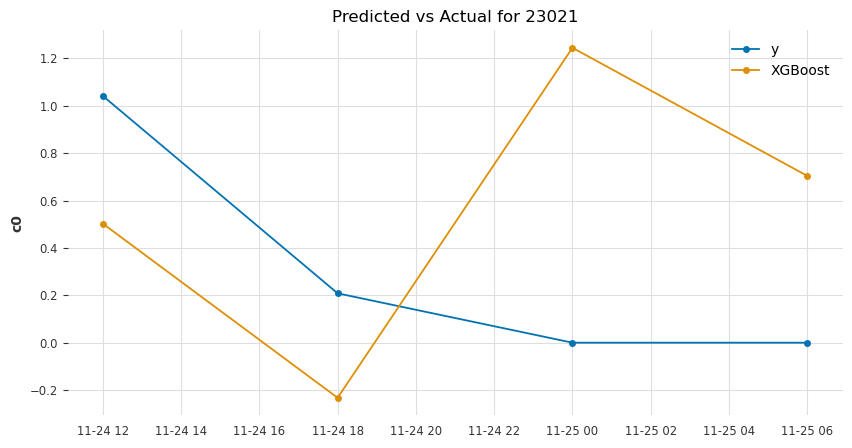

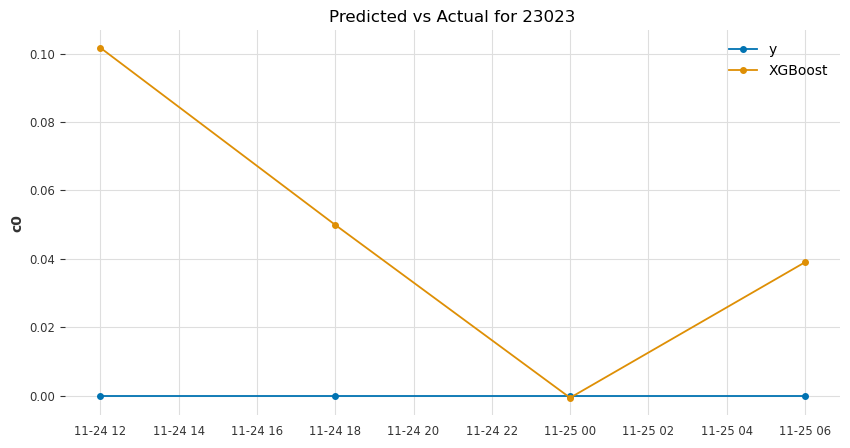

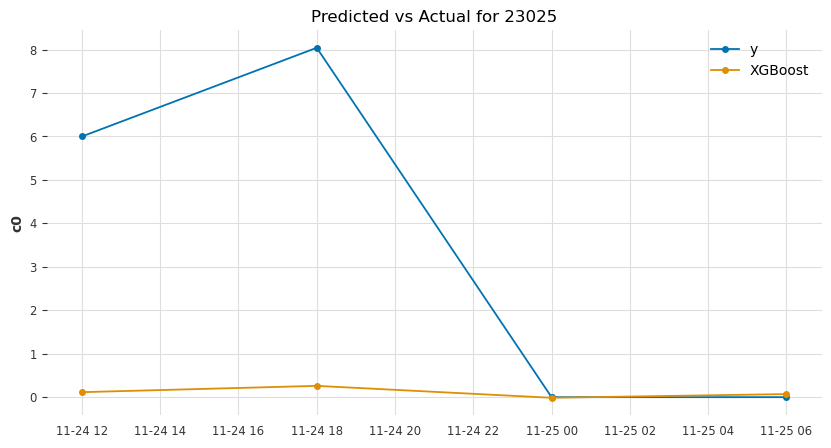

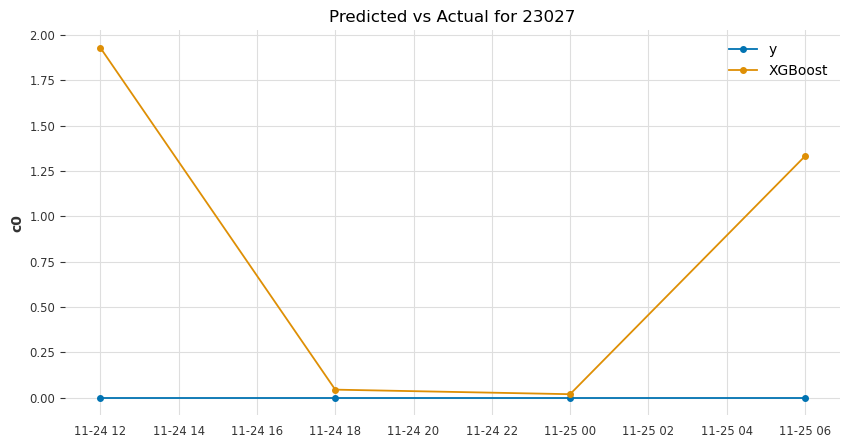

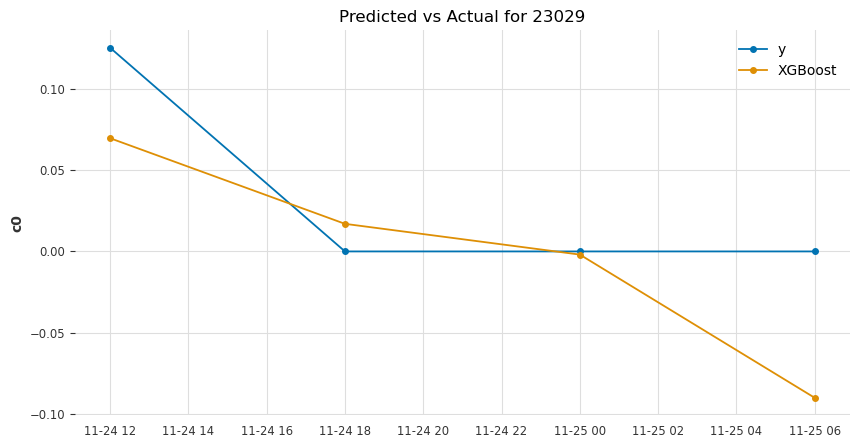

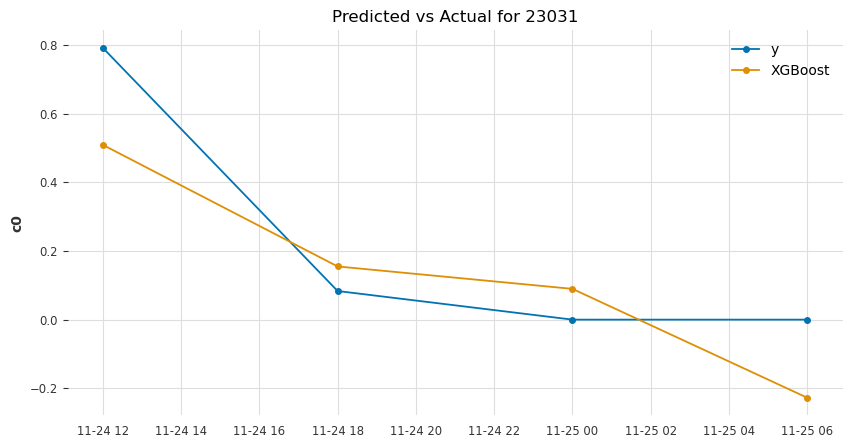

In [74]:
# Make a plot of results.y_test[0] and results.y_pred[0] for each value of fips_code
for fips_code in y.index.get_level_values(0).unique():
    y_test_fips = results.y_test[0].loc[fips_code]
    y_pred_fips = results.y_pred[0].loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plot_series(y_test_fips, y_pred_fips, labels=["y", "XGBoost"], ax=ax)
    plt.title(f'Predicted vs Actual for {fips_code}')
    plt.show()

### Evaluate performance

Not so hot!

In [81]:
results.test_MeanSquaredError

0      63.930754
1      45.095237
2      43.152405
3      59.566402
4      87.982598
         ...    
120    51.763159
121    53.169544
122    54.475818
123    34.907944
124    43.727588
Name: test_MeanSquaredError, Length: 125, dtype: float64

### Try it manually

For some reason getting worse predictions when doing it manually...?

In [82]:
#Use sw to make predictions of max values for y_small
mse = MeanSquaredError(square_root = True)
fh = np.arange(1, 13)

n_splits = ews.get_n_splits(y_small)

results = []

i=0
for train_idx, test_idx in ews.split(y_small):
    # Split the data
    y_small_train, y_small_test, X_small_train, X_small_test = y_small.iloc[train_idx], y_small.iloc[test_idx], X_small.iloc[train_idx], X_small.iloc[test_idx]

    # Fit the model
    dartsxgb.fit(y_small_train, X_small_train, ews.fh)
    
    # Predict
    y_small_pred = dartsxgb.predict(ews.fh, X_small_test)
    
    # Compute the maximum values of y for each fips code
    y_small_pred_max = y_small_pred.groupby(level=0).max()
    y_small_test_max = y_small_test.groupby(level=0).max()

    rmse = mse(y_small_pred_max, y_small_test_max)

    # Store the results
    results.append((i, rmse))
    i=i+1



In [83]:
results

[(0, 193.95515666049155),
 (1, 96.02287342478387),
 (2, 121.12729273906953),
 (3, 162.71003705958523),
 (4, 222.47854337999124),
 (5, 49.93392792646751),
 (6, 114.84377272703718),
 (7, 205.06625077909175),
 (8, 692.5905492450883),
 (9, 397.7185037820167),
 (10, 555.9842706629338),
 (11, 98.5545181266537),
 (12, 2304.013379090579),
 (13, 432.3468139267183),
 (14, 230.10224871527055),
 (15, 337.9844579615142),
 (16, 260.4518903469538),
 (17, 424.72192675122534),
 (18, 417.4296859447211),
 (19, 455.88118872382853),
 (20, 106.80785502196709),
 (21, 185.59272243144585),
 (22, 131.4445300439263),
 (23, 94.70162098886496),
 (24, 2059.037226573891),
 (25, 83.61759341685561),
 (26, 156.64890310022903),
 (27, 322.97894003857306),
 (28, 193.16229808486807),
 (29, 162.63050286913165),
 (30, 125.59735918682502),
 (31, 117.96131265009274),
 (32, 136.74127293844384),
 (33, 158.98233855451022),
 (34, 1618.2541028337898),
 (35, 240.74112824392807),
 (36, 325.0572404916223),
 (37, 218.72066330221264),
 